Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Load Cleaned Datasets

In [3]:
customers = pd.read_csv("../datasets/cleaned/customers_clean.csv")
orders = pd.read_csv("../datasets/cleaned/orders_clean.csv")
order_items = pd.read_csv("../datasets/cleaned/order_items_clean.csv")
payments = pd.read_csv("../datasets/cleaned/payments_clean.csv")

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

Dataset Summary

In [5]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.shape)
    print(df.head())

Customers
(99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
Orders
(96455, 5)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef4

EDA Roadmap

Part A – Univariate Analysis

Customer Distribution by State

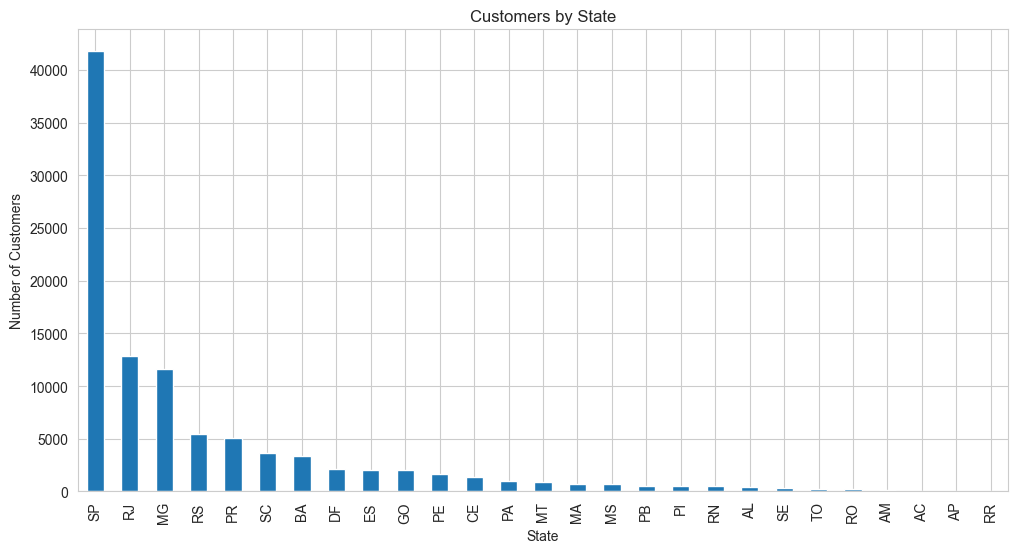

In [6]:
plt.figure(figsize=(12,6))

customers["customer_state"]\
.value_counts()\
.plot(kind="bar")

plt.title("Customers by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.show()

Top 20 Cities

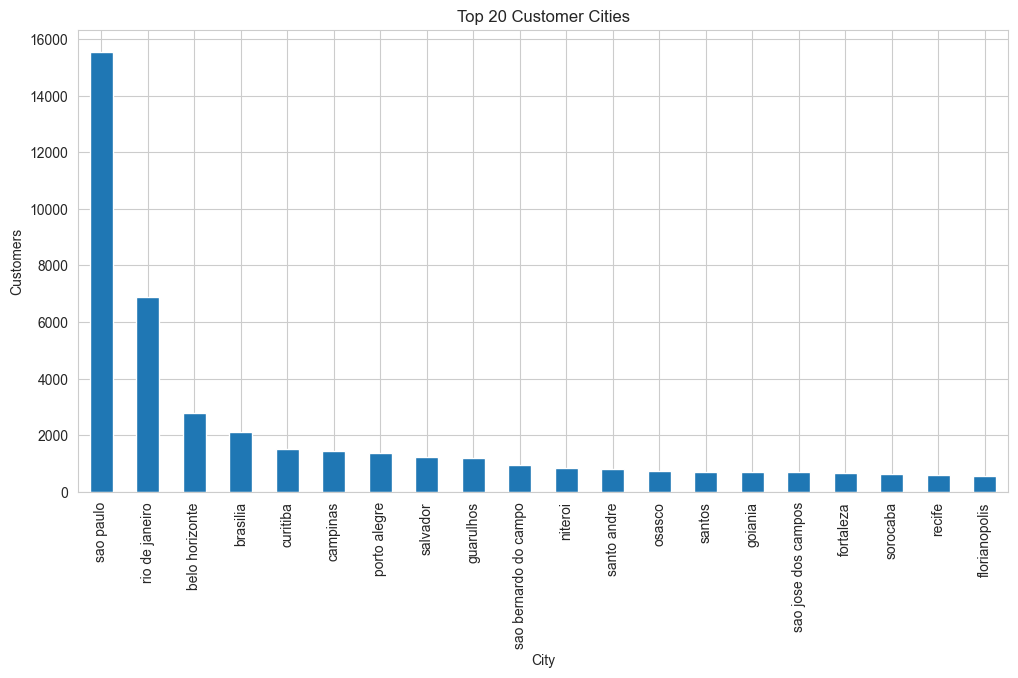

In [7]:
plt.figure(figsize=(12,6))

customers["customer_city"]\
.value_counts()\
.head(20)\
.plot(kind="bar")

plt.title("Top 20 Customer Cities")
plt.xlabel("City")
plt.ylabel("Customers")
plt.show()

Order Status

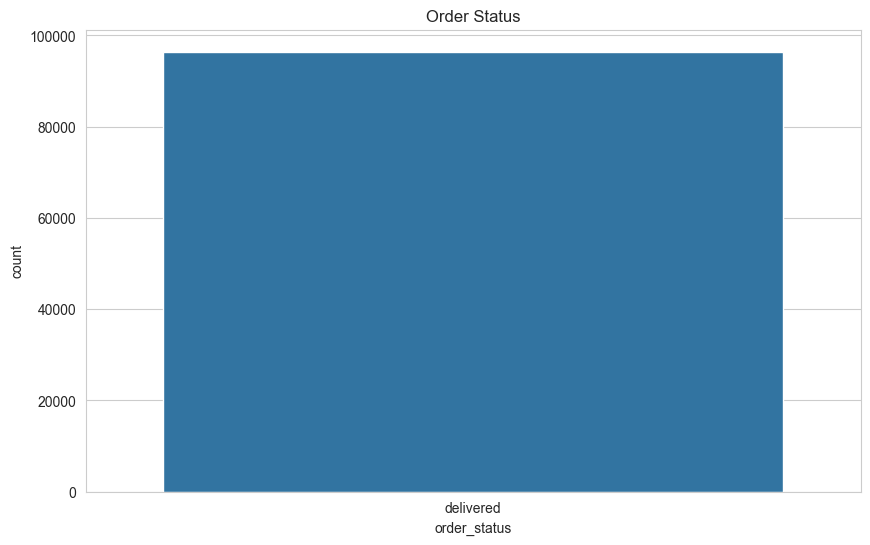

In [8]:
sns.countplot(
    x="order_status",
    data=orders
)

plt.title("Order Status")
plt.show()

Product Price Distribution

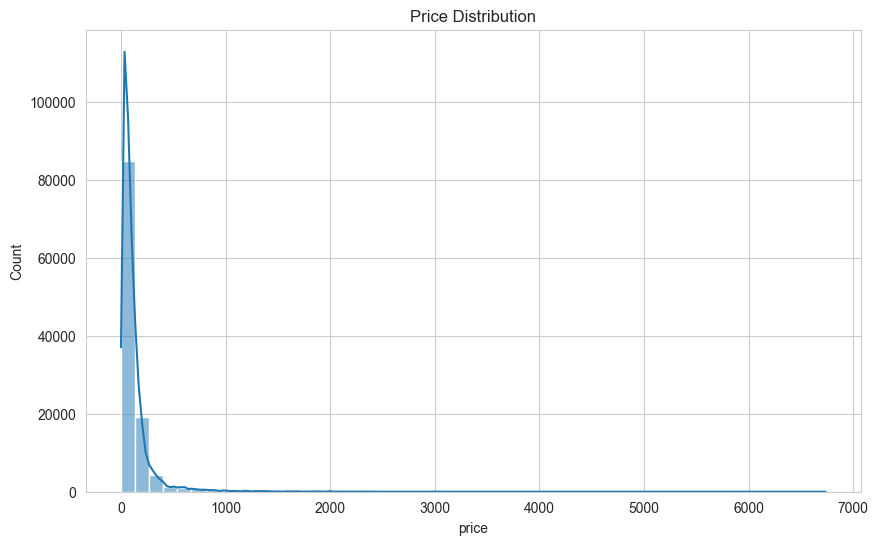

In [9]:
sns.histplot(
    order_items["price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution")
plt.show()

Boxplot of Product Price

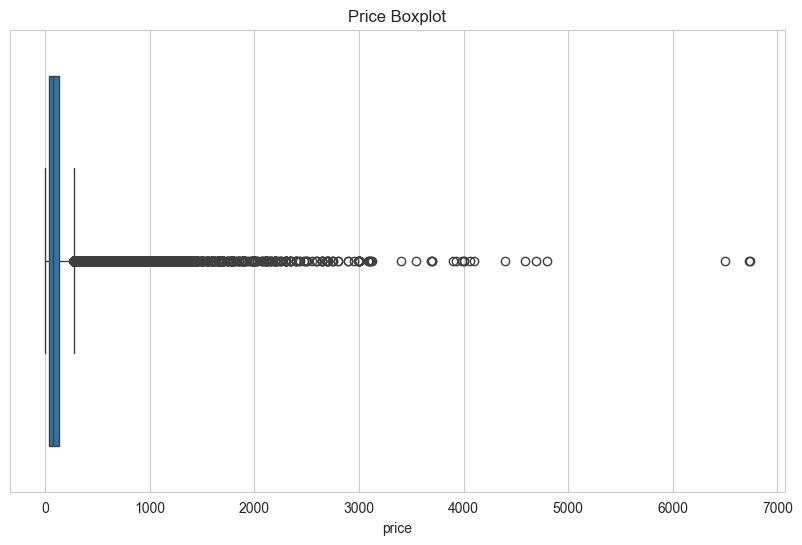

In [10]:
sns.boxplot(
    x=order_items["price"]
)

plt.title("Price Boxplot")
plt.show()

Freight Distribution

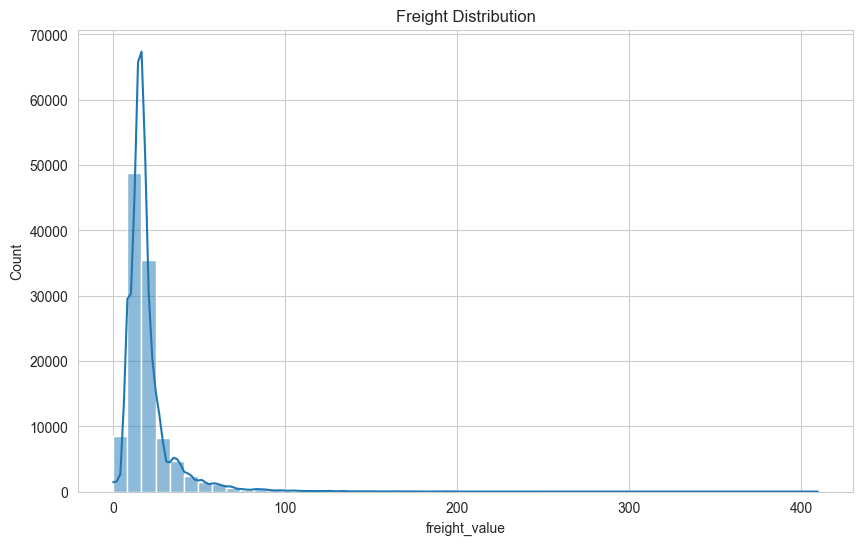

In [11]:
sns.histplot(
    order_items["freight_value"],
    bins=50,
    kde=True
)

plt.title("Freight Distribution")
plt.show()

Payment Value Distribution

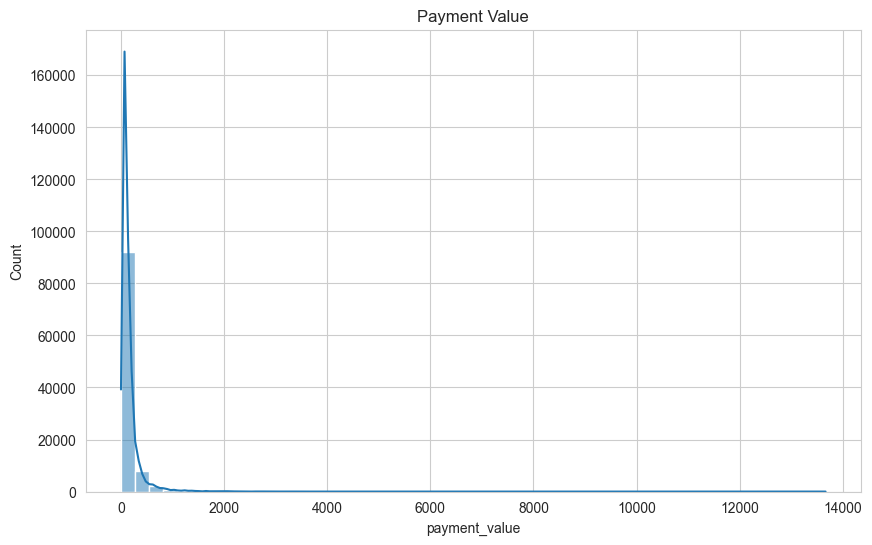

In [12]:
sns.histplot(
    payments["payment_value"],
    bins=50,
    kde=True
)

plt.title("Payment Value")
plt.show()

Payment Types

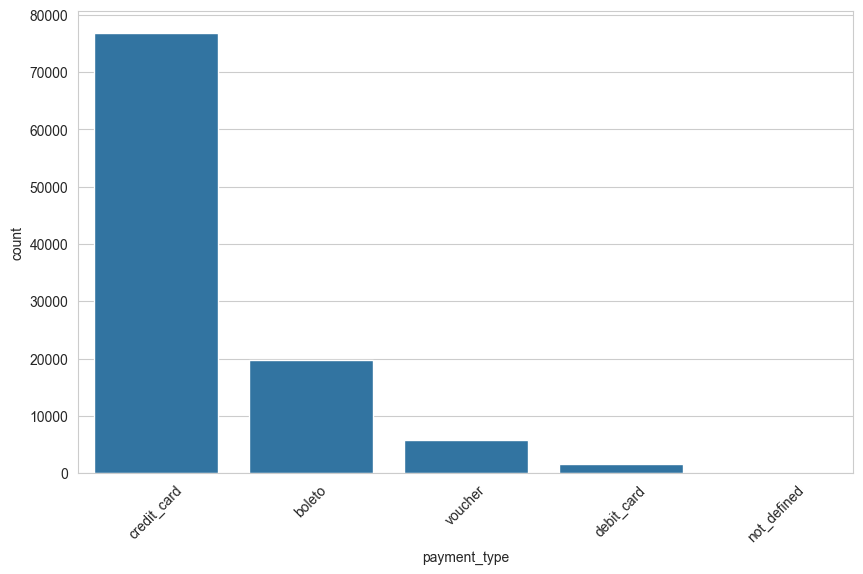

In [13]:
sns.countplot(
    x="payment_type",
    data=payments
)

plt.xticks(rotation=45)
plt.show()

PART B : TIME ANALYSIS

Orders Per Year

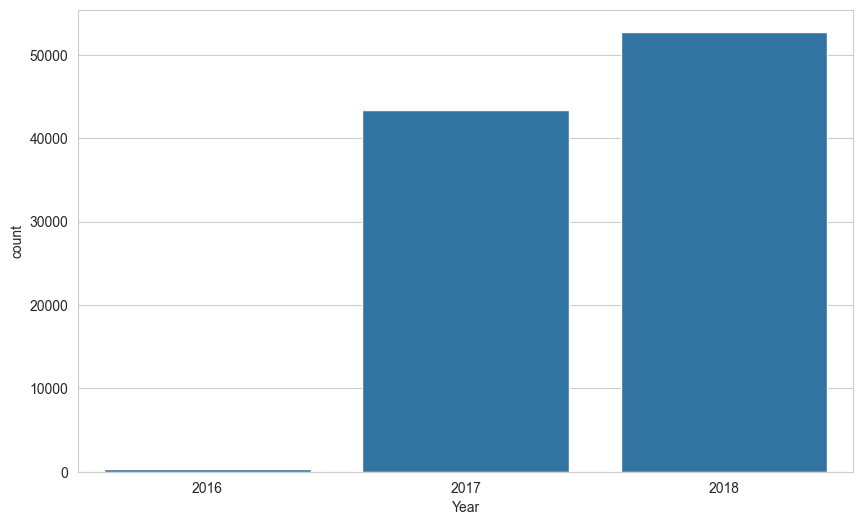

In [14]:
orders["Year"] = orders["order_purchase_timestamp"].dt.year

sns.countplot(
    x="Year",
    data=orders
)

plt.show()

Orders Per Month

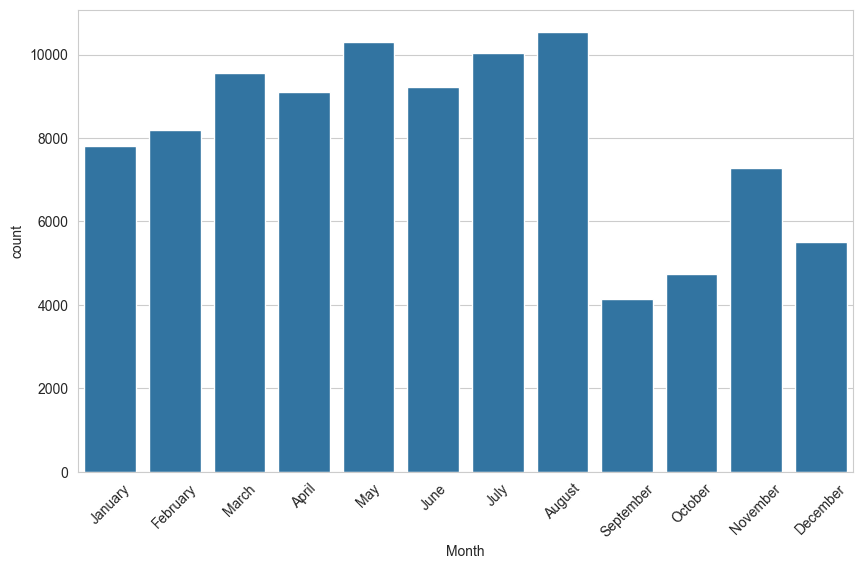

In [15]:
orders["Month"] = orders["order_purchase_timestamp"].dt.month_name()

month_order = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

sns.countplot(
    x="Month",
    data=orders,
    order=month_order
)

plt.xticks(rotation=45)
plt.show()

Orders by Weekday

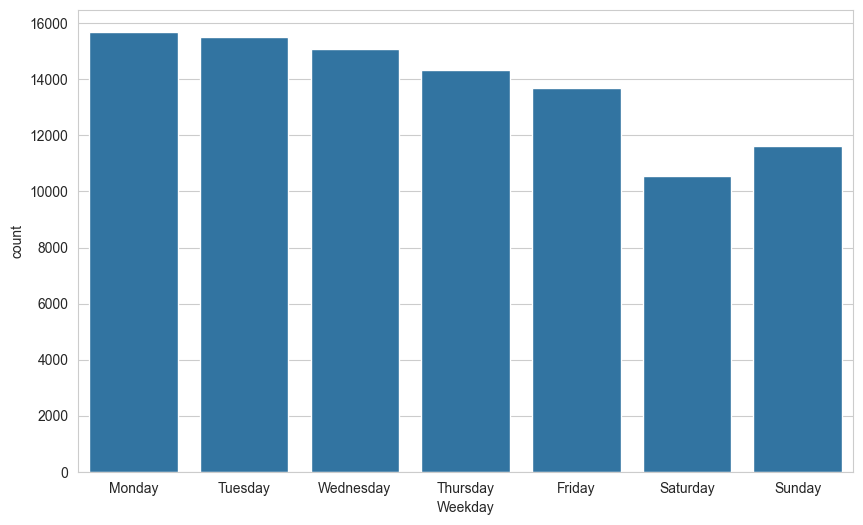

In [16]:
orders["Weekday"] = orders["order_purchase_timestamp"].dt.day_name()

weekday_order=[
'Monday','Tuesday','Wednesday',
'Thursday','Friday','Saturday','Sunday'
]

sns.countplot(
    x="Weekday",
    data=orders,
    order=weekday_order
)

plt.show()

PART C : CUSTOMER BEHAVIOUR

Orders per Customer

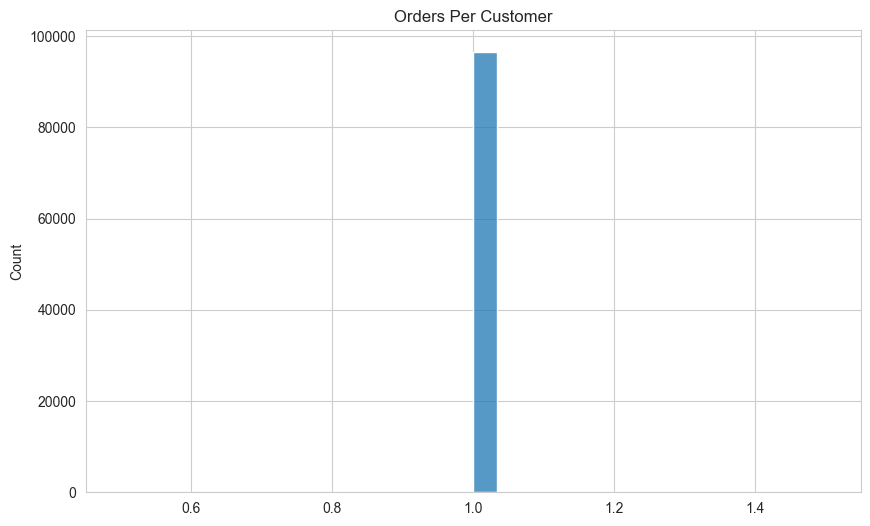

In [17]:
customer_orders = (
orders
.groupby("customer_id")
.size()
)

sns.histplot(
    customer_orders,
    bins=30
)

plt.title("Orders Per Customer")
plt.show()

In [19]:
#Product Price Statistics
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [20]:
#Freight Statistics
order_items["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [21]:
#Payment Statistics
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

PART D : BIVARIATE ANALYSIS

Price vs Freight

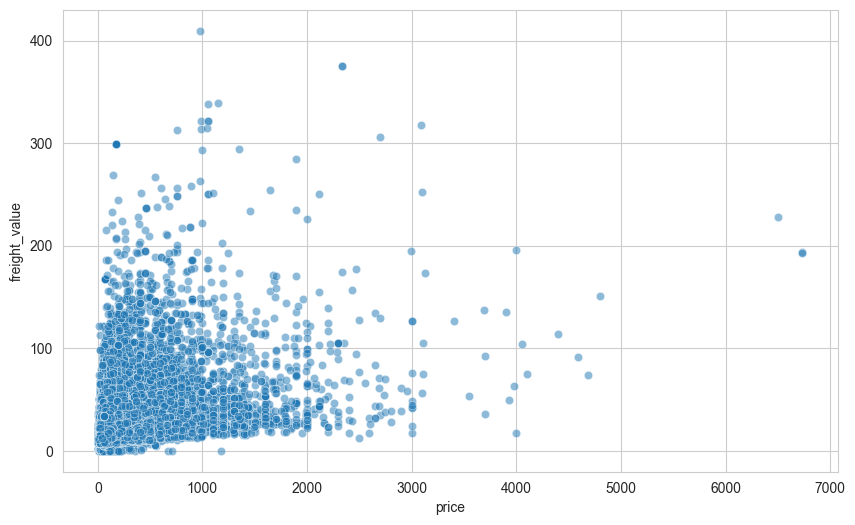

In [22]:
sns.scatterplot(
    x="price",
    y="freight_value",
    data=order_items,
    alpha=0.5
)

plt.show()

Payment Installments vs Payment Value

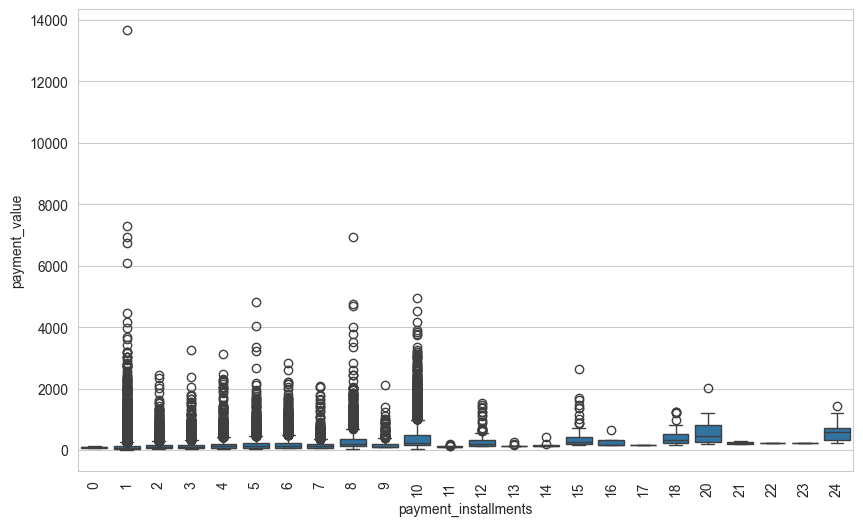

In [23]:
sns.boxplot(
    x="payment_installments",
    y="payment_value",
    data=payments
)

plt.xticks(rotation=90)
plt.show()

Correlation Matrix

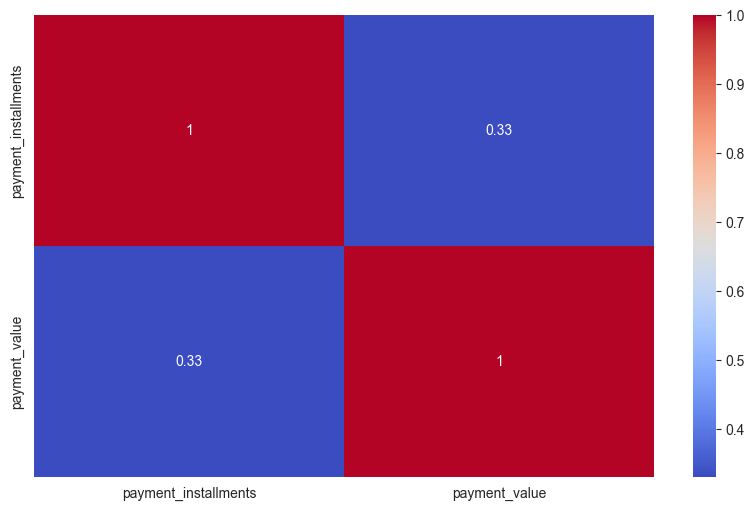

In [24]:
numeric = payments.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

PART E : OUTLIERS

Price Outliers

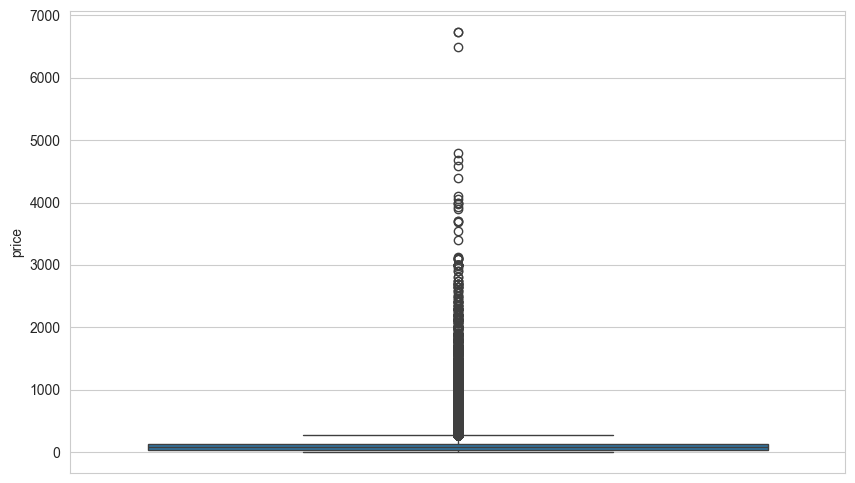

In [25]:
sns.boxplot(
    y=order_items["price"]
)

plt.show()

Freight Outliers

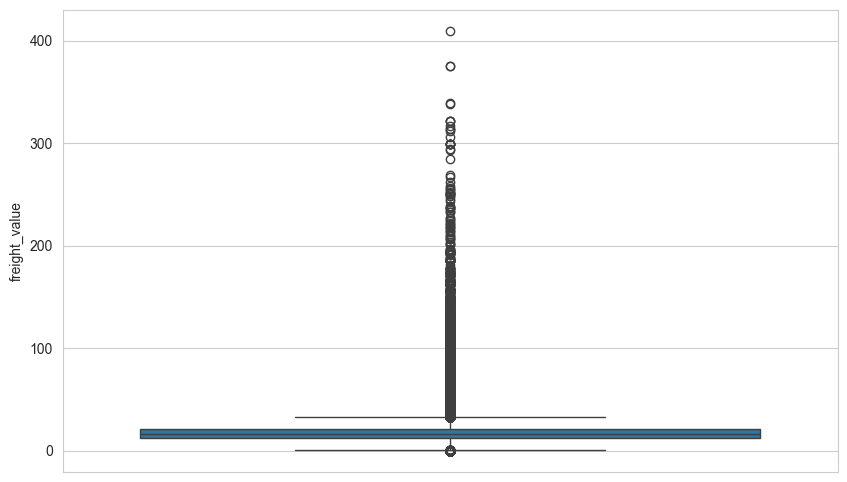

In [26]:
sns.boxplot(
    y=order_items["freight_value"]
)

plt.show()

Payment Outliers

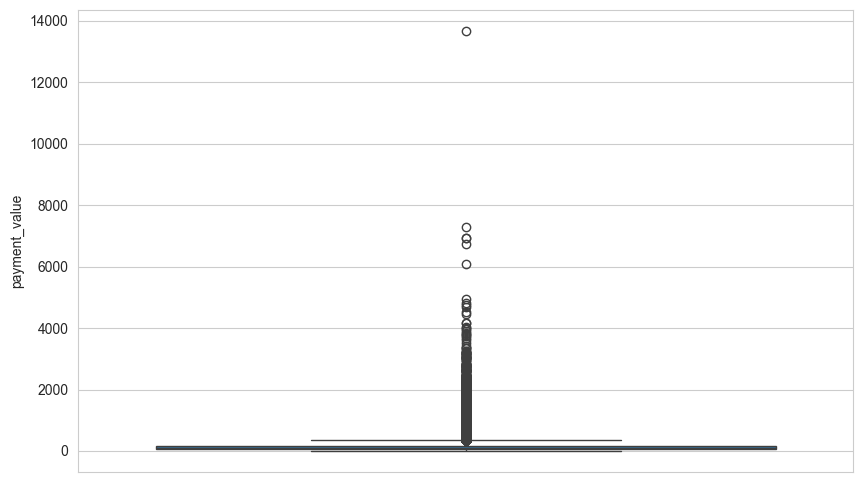

In [27]:
sns.boxplot(
    y=payments["payment_value"]
)

plt.show()